# Discount Price Regression and Final Prediction

In [1]:
from pathlib import Path
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "8"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/discountmate-matplotlib")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, precision_recall_curve
from xgboost import XGBRegressor

DATA_FILE = Path("discount_price_final_dataset.csv")
if not DATA_FILE.exists():
    DATA_FILE = Path("ML/Price-Prediction/price_prediction_by_shivam/discount_price_final_dataset.csv")

data = pd.read_csv(DATA_FILE, parse_dates=["catalogue_start_date"])
regression_data = data[data["discount_regression_eligible"].eq(1)].copy()
print(f"Discount regression rows: {len(regression_data):,}")
print(f"Products: {regression_data['product_id'].nunique():,}")
print(f"Weeks: {regression_data['catalogue_start_date'].nunique()}")
regression_data["target_discount_percent_next_week"].describe()

Discount regression rows: 2,376
Products: 783
Weeks: 52


count    2376.000000
mean       37.270574
std        13.313223
min         4.838710
25%        25.000000
50%        40.000000
75%        50.000000
max        74.166667
Name: target_discount_percent_next_week, dtype: float64

## Features and chronological split

In [2]:
categorical_features = ["retailer", "region", "season", "promo_type", "regular_price_source"]
features = [
    "retailer", "region", "catalogue_observed", "special_price_clean",
    "regular_price_filled", "effective_price", "price_inferred",
    "price_trustworthy", "price_outlier", "is_special", "discount_percent",
    "discount_percent_trustworthy", "history_count", "cold_start_product",
    "price_lag_1", "price_lag_2", "price_lag_4", "discount_lag_1",
    "avg_price_4w", "avg_price_8w", "special_frequency_4w",
    "special_frequency_8w", "weeks_since_last_special",
    "weeks_since_regular_price", "week_of_year", "month", "quarter",
    "season", "promo_type", "regular_price_source",
]

X = pd.get_dummies(
    regression_data[features], columns=categorical_features, dummy_na=True, dtype=float
)
y = regression_data["target_discount_percent_next_week"]

all_dates = sorted(data.loc[data["classification_eligible"].eq(1), "catalogue_start_date"].unique())
validation_start = all_dates[-16]
test_start = all_dates[-8]
train_mask = regression_data["catalogue_start_date"].lt(validation_start)
validation_mask = regression_data["catalogue_start_date"].ge(validation_start) & regression_data["catalogue_start_date"].lt(test_start)
test_mask = regression_data["catalogue_start_date"].ge(test_start)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_validation, y_validation = X.loc[validation_mask], y.loc[validation_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

print(f"Train: {len(y_train):,} rows")
print(f"Validation: {len(y_validation):,} rows")
print(f"Test: {len(y_test):,} rows")

Train: 1,670 rows
Validation: 430 rows
Test: 276 rows


## Compare regression models

In [3]:
models = {
    "Median Baseline": make_pipeline(SimpleImputer(strategy="median"), DummyRegressor(strategy="median")),
    "Ridge Regression": make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Ridge(alpha=10)),
    "Random Forest": make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestRegressor(n_estimators=300, max_depth=14, min_samples_leaf=2, n_jobs=-1, random_state=42),
    ),
    "Extra Trees": make_pipeline(
        SimpleImputer(strategy="median"),
        ExtraTreesRegressor(n_estimators=300, max_depth=14, min_samples_leaf=2, n_jobs=-1, random_state=42),
    ),
    "HistGradientBoosting": make_pipeline(
        SimpleImputer(strategy="median"),
        HistGradientBoostingRegressor(max_iter=250, learning_rate=0.05, max_leaf_nodes=31, l2_regularization=1, random_state=42),
    ),
    "XGBoost": make_pipeline(
        SimpleImputer(strategy="median"),
        XGBRegressor(n_estimators=350, max_depth=4, learning_rate=0.04, subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror", n_jobs=-1, random_state=42),
    ),
    "Neural Network (MLP)": make_pipeline(
        SimpleImputer(strategy="median"), StandardScaler(),
        MLPRegressor(hidden_layer_sizes=(64, 32), early_stopping=True, max_iter=600, random_state=42),
    ),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    validation_prediction = np.clip(model.predict(X_validation), 0, 80)
    test_prediction = np.clip(model.predict(X_test), 0, 80)
    results.append({
        "Model": name,
        "Validation MAE": mean_absolute_error(y_validation, validation_prediction),
        "Test MAE": mean_absolute_error(y_test, test_prediction),
        "Test RMSE": mean_squared_error(y_test, test_prediction) ** 0.5,
        "Test R2": r2_score(y_test, test_prediction),
    })

comparison = pd.DataFrame(results).sort_values("Validation MAE").reset_index(drop=True)
comparison.round(3)

,Model,Validation MAE,Test MAE,Test RMSE,Test R2
0,HistGradientBoosting,8.015,9.139,11.267,0.347
1,Random Forest,8.264,9.391,11.291,0.344
2,Extra Trees,8.308,9.716,11.764,0.288
3,XGBoost,8.409,9.369,11.121,0.364
4,Neural Network (MLP),10.450,11.548,13.761,0.025
5,Ridge Regression,10.915,11.842,13.516,0.060
6,Median Baseline,11.626,12.027,14.069,-0.019


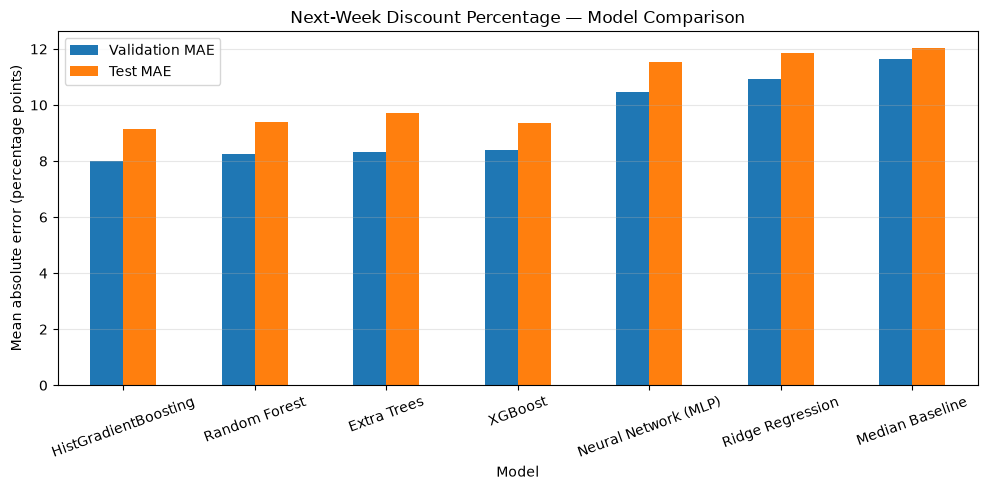

In [4]:
comparison.set_index("Model")[["Validation MAE", "Test MAE"]].plot(
    kind="bar", figsize=(10, 5), rot=20
)
plt.title("Next-Week Discount Percentage — Model Comparison")
plt.ylabel("Mean absolute error (percentage points)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Train and save the combined model

In [5]:
best_name = comparison.iloc[0]["Model"]
final_regressor = clone(models[best_name])
final_regressor.fit(X, y)

classifier_features = [
    "catalogue_observed", "effective_price", "price_inferred", "price_trustworthy",
    "price_outlier", "is_special", "discount_percent", "history_count",
    "cold_start_product", "price_lag_1", "price_lag_2", "price_lag_4",
    "discount_lag_1", "avg_price_4w", "avg_price_8w",
    "special_frequency_4w", "special_frequency_8w", "weeks_since_last_special",
    "weeks_since_regular_price", "week_of_year", "month", "quarter",
    "season", "promo_type", "regular_price_source",
]
classifier_categorical = ["season", "promo_type", "regular_price_source"]
classification_data = data[data["classification_eligible"].eq(1)].copy()
X_classifier = pd.get_dummies(
    classification_data[classifier_features],
    columns=classifier_categorical, dummy_na=True, dtype=float,
)
y_classifier = classification_data["target_is_special_next_week"].astype(int)
classifier_train_mask = classification_data["catalogue_start_date"].lt(validation_start)
classifier_validation_mask = (
    classification_data["catalogue_start_date"].ge(validation_start)
    & classification_data["catalogue_start_date"].lt(test_start)
)
classifier_model = make_pipeline(
    SimpleImputer(strategy="median"), StandardScaler(),
    LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42),
)
classifier_model.fit(X_classifier.loc[classifier_train_mask], y_classifier.loc[classifier_train_mask])
validation_probability = classifier_model.predict_proba(X_classifier.loc[classifier_validation_mask])[:, 1]
precision, recall, thresholds = precision_recall_curve(
    y_classifier.loc[classifier_validation_mask], validation_probability
)
validation_f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
classifier_threshold = float(thresholds[np.argmax(validation_f1)])
final_classifier = clone(classifier_model).fit(X_classifier, y_classifier)

combined_model = {
    "classifier": final_classifier,
    "classifier_name": "Logistic Regression",
    "classifier_threshold": classifier_threshold,
    "classifier_raw_features": classifier_features,
    "classifier_columns": X_classifier.columns.tolist(),
    "regressor": final_regressor,
    "regressor_name": best_name,
    "regressor_raw_features": features,
    "regressor_columns": X.columns.tolist(),
    "categorical_features": categorical_features,
    "discount_rounding_step": 5,
    "training_start": str(data["catalogue_start_date"].min().date()),
    "training_end": str(data["catalogue_start_date"].max().date()),
}

MODEL_FILE = DATA_FILE.parent / "discount_price_prediction_model.joblib"
joblib.dump(combined_model, MODEL_FILE)

best = comparison.iloc[0]
print(f"Best discount model: {best_name}")
print(f"Validation MAE: {best['Validation MAE']:.2f} percentage points")
print(f"Test MAE: {best['Test MAE']:.2f} percentage points")
print(f"Test RMSE: {best['Test RMSE']:.2f} | Test R2: {best['Test R2']:.3f}")
print(f"Classifier retrained locally on all {len(y_classifier):,} eligible rows")
print(f"Classifier threshold: {classifier_threshold:.3f}")
print(f"Final regressor trained on all {len(y):,} trustworthy discounted rows")
print(f"Saved combined model: {MODEL_FILE.resolve()}")

Best discount model: HistGradientBoosting
Validation MAE: 8.01 percentage points
Test MAE: 9.14 percentage points
Test RMSE: 11.27 | Test R2: 0.347
Classifier retrained locally on all 44,640 eligible rows
Classifier threshold: 0.688
Final regressor trained on all 2,376 trustworthy discounted rows
Saved combined model: /Users/shivamsaini/Desktop/Deakin/SIT 782/DiscountMate_new/ML/Price-Prediction/price_prediction_by_shivam/discount_price_prediction_model.joblib


## Predict next week's special and price

In [6]:
def prepare_model_input(rows, raw_features, model_columns, categorical):
    categorical = [column for column in categorical if column in raw_features]
    values = pd.get_dummies(rows[raw_features], columns=categorical, dummy_na=True, dtype=float)
    return values.reindex(columns=model_columns, fill_value=0)

def predict_next_week_offer(rows, bundle=combined_model):
    classifier_input = prepare_model_input(
        rows, bundle["classifier_raw_features"], bundle["classifier_columns"],
        ["season", "promo_type", "regular_price_source"],
    )
    regressor_input = prepare_model_input(
        rows, bundle["regressor_raw_features"], bundle["regressor_columns"],
        bundle["categorical_features"],
    )

    special_probability = bundle["classifier"].predict_proba(classifier_input)[:, 1]
    raw_discount = bundle["regressor"].predict(regressor_input)
    rounding_step = bundle.get("discount_rounding_step", 5)
    predicted_discount = np.clip(np.round(raw_discount / rounding_step) * rounding_step, 0, 80)
    regular_price = pd.to_numeric(rows["regular_price_filled"], errors="coerce").to_numpy()
    predicted_special_price = regular_price * (1 - predicted_discount / 100)
    expected_price = regular_price * (1 - special_probability * predicted_discount / 100)
    predicted_is_special = special_probability >= bundle["classifier_threshold"]

    output = rows[["product_id", "canonical_product_name"]].reset_index(drop=True).copy()
    output["regular_price_reference"] = np.round(regular_price, 2)
    output["special_probability"] = np.round(special_probability, 3)
    output["predicted_is_special"] = predicted_is_special
    output["predicted_discount_percent_if_special"] = np.round(predicted_discount, 1)
    output["predicted_special_price_if_special"] = np.round(predicted_special_price, 2)
    output["probability_weighted_expected_price"] = np.round(expected_price, 2)
    return output

latest_rows = data.sort_values("catalogue_start_date").groupby("product_id").tail(1)
example_predictions = predict_next_week_offer(latest_rows)
likely_specials = example_predictions[
    example_predictions["predicted_is_special"] & example_predictions["regular_price_reference"].notna()
].sort_values("special_probability", ascending=False)
print(f"Latest products scored: {len(example_predictions):,}")
print(f"Predicted likely specials: {len(likely_specials):,}")
likely_specials.head(10)

Latest products scored: 6,784
Predicted likely specials: 118


,product_id,canonical_product_name,regular_price_reference,special_probability,predicted_is_special,predicted_discount_percent_if_special,predicted_special_price_if_special,probability_weighted_expected_price
6689,P00122,pepsi or solo 1.25 l,3.50,0.973,True,50.0,1.75,1.80
6263,P00384,kirks 10x375ml,15.00,0.970,True,50.0,7.50,7.72
6774,P01680,connoisseur ice cream tub 1 l,12.00,0.943,True,45.0,6.60,6.91
6724,P00950,v energy drink 4x250ml,11.75,0.940,True,45.0,6.46,6.78
6273,P00429,streets golden gaytime sticks 4 pack 400ml,10.00,0.939,True,45.0,5.50,5.77
6632,P00312,lipton ice tea 1.5 l,5.50,0.935,True,50.0,2.75,2.93
6411,P00045,morning fresh dishwashing liquid 900ml,10.00,0.922,True,45.0,5.50,5.85
6492,P01108,sunbites grain waves 170g,5.00,0.899,True,45.0,2.75,2.98
5964,P01149,lindt lindor gift box 232g 235g,28.00,0.896,True,45.0,15.40,16.71
6255,P00385,red bull energy drink 4x250ml,12.50,0.892,True,45.0,6.88,7.48
